In [18]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as TF
import torch.nn.functional as F
import torchvision.transforms.v2 as transforms

In [2]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [42]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()

        self.encoders = nn.ModuleList()
        prev_channels = in_channels

        for feature in features:
            self.encoders.append(nn.Sequential(
                nn.Conv2d(prev_channels, feature, kernel_size=3, padding=1),
                nn.BatchNorm2d(feature),
                nn.ReLU(inplace=True),
                nn.Conv2d(feature, feature, kernel_size=3, padding=1),
                nn.BatchNorm2d(feature),
                nn.ReLU(inplace=True)
            ))
            prev_channels = feature

        self.bottleneck = nn.Sequential(
            nn.Conv2d(prev_channels, prev_channels * 2, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(prev_channels * 2, prev_channels * 2, 3, padding=1),
            nn.ReLU(inplace=True)
        )

        self.decoders = nn.ModuleList()
        in_channels_decoder = prev_channels * 2

        for feature in reversed(features):
            self.decoders.append(
                nn.ConvTranspose2d(in_channels_decoder, feature, kernel_size=2, stride=2)
            )

            self.decoders.append(nn.Sequential(
                nn.Conv2d(feature * 2, feature, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(feature, feature, kernel_size=3, padding=1),
                nn.ReLU(inplace=True)
            ))

            in_channels_decoder = feature

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
      enc_features = []

      for encode in self.encoders:
          x = encode(x)
          enc_features.append(x)
          x = F.max_pool2d(x, kernel_size=2)

      x = self.bottleneck(x)

      enc_features = enc_features[::-1]

      for idx in range(0, len(self.decoders), 2):
          x = self.decoders[idx](x)
          skip_feat = enc_features[idx // 2]

          if x.shape != skip_feat.shape:
              x = F.interpolate(x, size=skip_feat.shape[2:])

          x = torch.cat([skip_feat, x], dim=1)
          x = self.decoders[idx + 1](x)

      return self.final_conv(x)

In [19]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = TF.pil_to_tensor(mask).float()

        return image, mask

In [39]:
class Trainer:
    def __init__(self, config):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        self.model = UNet().to(config.device)
        self.criterion = nn.BCEWithLogitsLoss() # какой лосс удобный возьмем для бинарной сегментации?
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        self.history = {
              "train_loss": [],
              "val_loss": [],
              "val_iou": [],
              "val_f1": []
          }

        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["val_iou"].append(val_iou)
            self.history["val_f1"].append(val_f1)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()


In [36]:
trainer = Trainer(config)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [37]:
trainer.run()

100%|██████████| 23/23 [00:11<00:00,  1.95it/s]


Epoch 1 / 15, Train Loss: 0.5227, Val Loss: 0.4493, Val IoU: 0.7629, Val F1-score: 0.8594


100%|██████████| 23/23 [00:11<00:00,  1.93it/s]


Epoch 2 / 15, Train Loss: 0.3884, Val Loss: 0.3901, Val IoU: 0.7723, Val F1-score: 0.8653


100%|██████████| 23/23 [00:11<00:00,  1.98it/s]


...

Epoch 14 / 15, Train Loss: 0.1411, Val Loss: 0.1969, Val IoU: 0.8890, Val F1-score: 0.9383


100%|██████████| 23/23 [00:11<00:00,  1.93it/s]


Epoch 15 / 15, Train Loss: 0.1247, Val Loss: 0.1856, Val IoU: 0.8967, Val F1-score: 0.9431
Testing...


100%|██████████| 115/115 [01:01<00:00,  1.88it/s]

Test Loss: 0.1989, Test IoU: 0.8910, Test F1-score: 0.9384


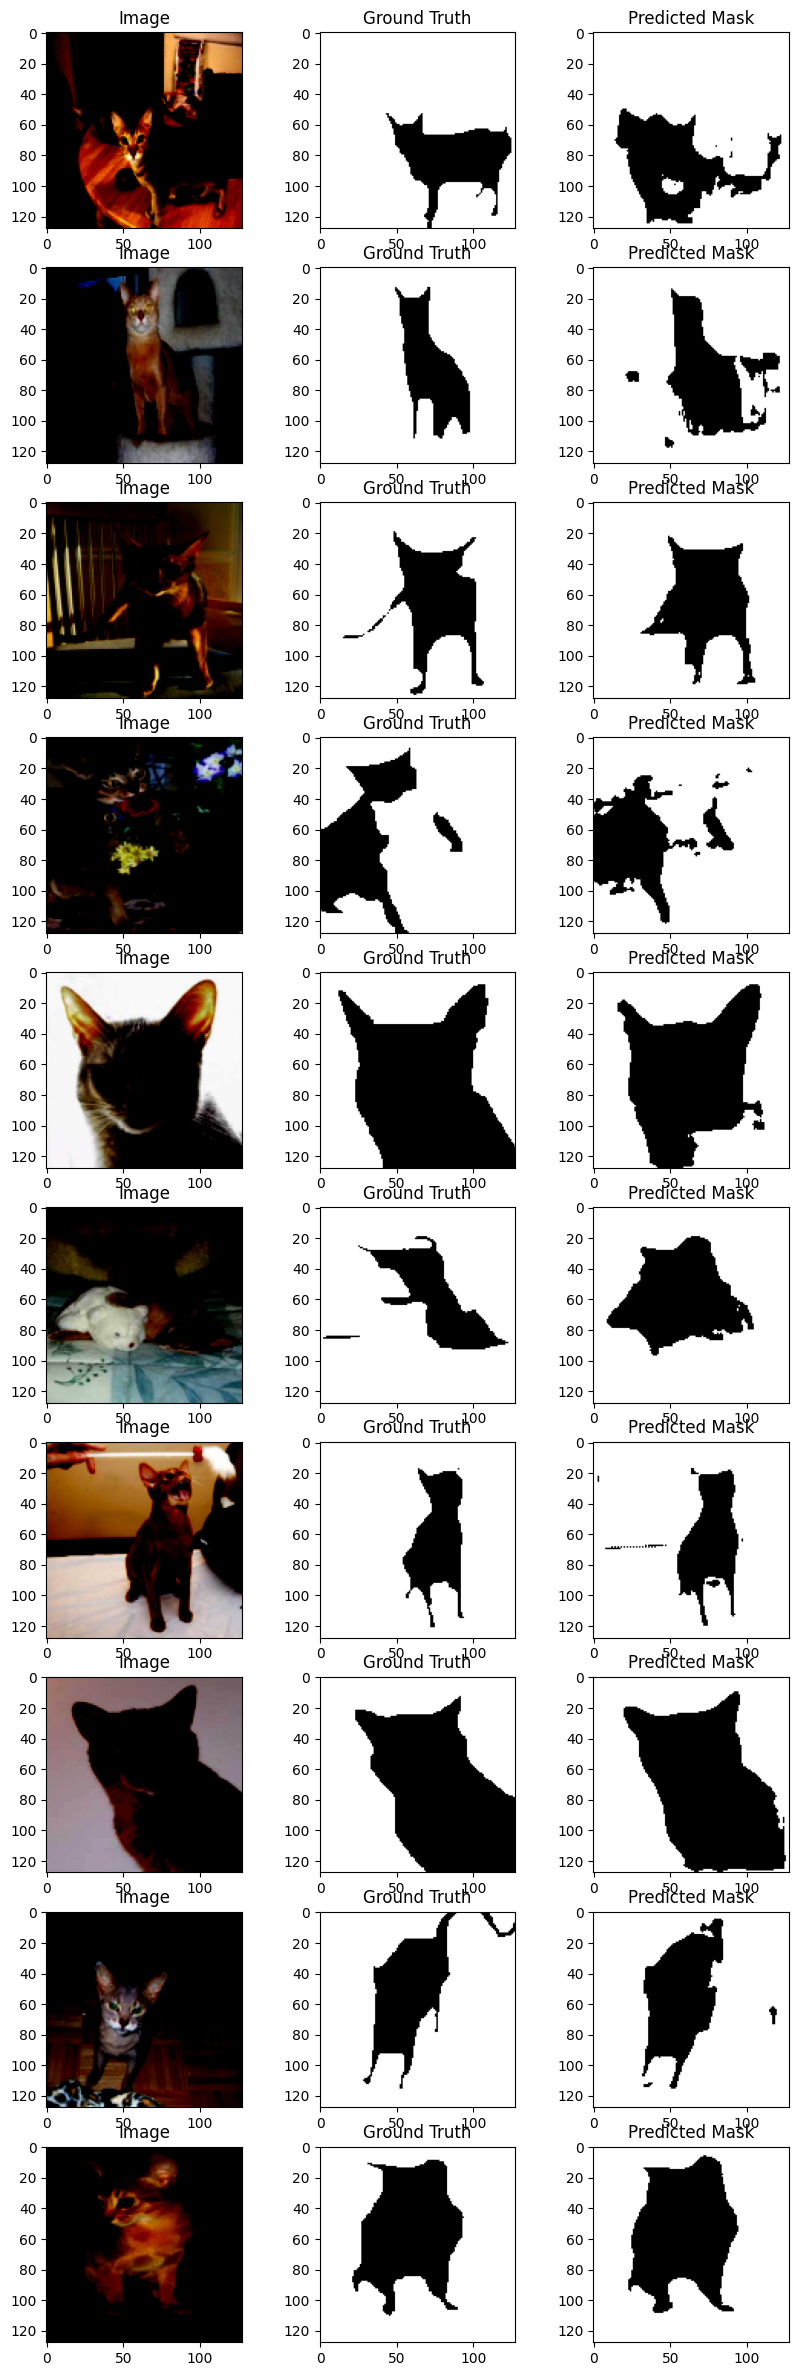

In [51]:
trainer.inference_and_plot_samples(n_samples=10)

### Перебор параметров

In [40]:
learning_rates = [1e-4, 5e-4, 1e-3]
batch_sizes = [16, 32, 64]

results = []
all_histories = {}

In [43]:
for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\n===== Training: lr={lr}, batch_size={bs} =====")

        config = Config()
        config.learning_rate = lr
        config.batch_size = bs
        config.epochs = 15

        trainer = Trainer(config)
        trainer.run()

        key = f"lr={lr}_bs={bs}"
        all_histories[key] = trainer.history

        results.append({
            "lr": lr,
            "batch_size": bs,
            "val_iou": trainer.history["val_iou"][-1],
            "val_f1": trainer.history["val_f1"][-1]
        })


===== Training: lr=0.0001, batch_size=16 =====


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:12<00:00,  3.64it/s]


Epoch 1 / 15, Train Loss: 0.4677, Val Loss: 0.3722, Val IoU: 0.7821, Val F1-score: 0.8732


100%|██████████| 46/46 [00:12<00:00,  3.57it/s]


Epoch 2 / 15, Train Loss: 0.3300, Val Loss: 0.3151, Val IoU: 0.8109, Val F1-score: 0.8898


...

Epoch 14 / 15, Train Loss: 0.2118, Val Loss: 0.2276, Val IoU: 0.8694, Val F1-score: 0.9254


100%|██████████| 12/12 [00:12<00:00,  1.05s/it]


Epoch 15 / 15, Train Loss: 0.2069, Val Loss: 0.2207, Val IoU: 0.8675, Val F1-score: 0.9251
Testing...


100%|██████████| 58/58 [01:03<00:00,  1.09s/it]

Test Loss: 0.2346, Test IoU: 0.8586, Test F1-score: 0.9187


In [44]:
import pandas as pd

df = pd.DataFrame(results)
df

,lr,batch_size,val_iou,val_f1
0,0.0001,16,0.889567,0.937780
1,0.0001,32,0.870574,0.926374
2,0.0001,64,0.874692,0.928948
3,0.0005,16,0.883796,0.933932
4,0.0005,32,0.883309,0.933631
5,0.0005,64,0.885477,0.936258
6,0.0010,16,0.868810,0.924688
7,0.0010,32,0.850375,0.914574
8,0.0010,64,0.867538,0.925134


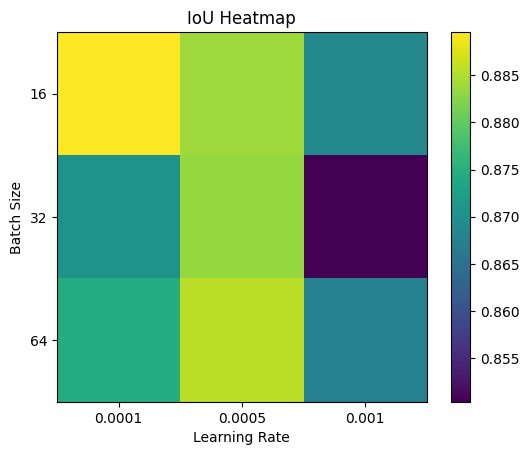

In [45]:
pivot_iou = df.pivot(index="batch_size", columns="lr", values="val_iou")

plt.figure()
plt.imshow(pivot_iou)

plt.xticks(range(len(learning_rates)), learning_rates)
plt.yticks(range(len(batch_sizes)), batch_sizes)

plt.xlabel("Learning Rate")
plt.ylabel("Batch Size")
plt.title("IoU Heatmap")

plt.colorbar()
plt.show()

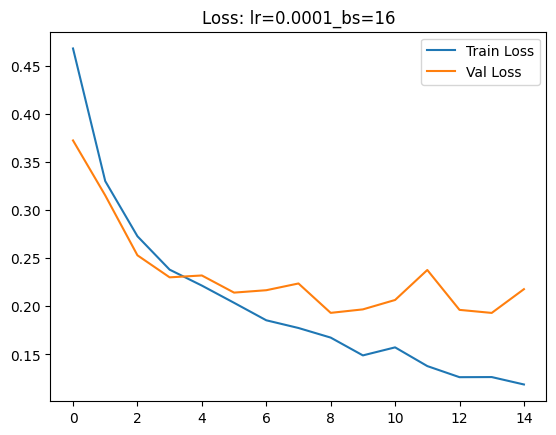

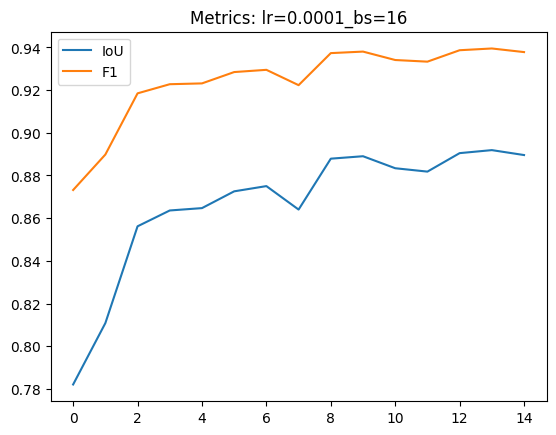

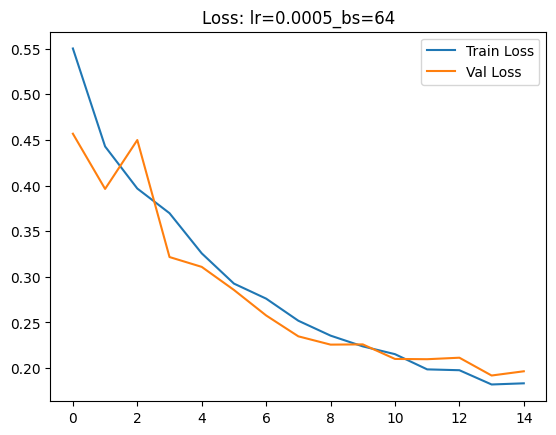

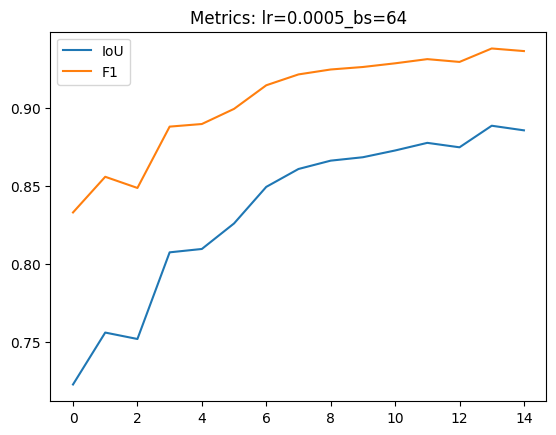

In [47]:
top_models = df.sort_values(by="val_iou", ascending=False).head(2)

for _, row in top_models.iterrows():
    lr = float(row["lr"])
    bs = int(row["batch_size"])

    key = f"lr={lr}_bs={bs}"

    history = all_histories[key]

    plt.figure()
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title(f"Loss: {key}")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history["val_iou"], label="IoU")
    plt.plot(history["val_f1"], label="F1")
    plt.title(f"Metrics: {key}")
    plt.legend()
    plt.show()

In [49]:
best = df.sort_values(by="val_iou", ascending=False).iloc[0]

print(f"Лучшая модель:")
print(f"Learning rate: {best['lr']}")
print(f"Batch size: {best['batch_size']}")
print(f"IoU: {best['val_iou']:.4f}")
print(f"F1: {best['val_f1']:.4f}\n")

Лучшая модель:
Learning rate: 0.0001
Batch size: 16.0
IoU: 0.8896
F1: 0.9378



### Выводы
- чем меньше learning rate, тем выше точность, но ниже скорость обучения
- небольшой batch size точнее, но захватывает больше шума; при большом batch size возможно переобучение
- оптимальный результат достигается при lr=0.0001, bs=16.0

возможно получилось бы достичь результата получше, еще сильнее уменьшив lr, но текущее обучение заняло 3 часа, это слишком долго...